
# A gentle introduction to wavelet for data analysis
[notebook](https://www.kaggle.com/code/asauve/a-gentle-introduction-to-wavelet-for-data-analysis/notebook)

## Introduction

Recently I had to do a preliminatory analysis on birth data. I wanted to use continuous wavelet transform to plot a spectrum of the dataset to get quick insights. Wavelets are specially well suited for this job. I expected to be able from python to do something like view(data, scales), and get a plot with meaningful labels on the axis. As I did not used wavelets for quite some time, it did not went that way and I spent quite a long time to get painfully some visualization with the Y axis labelled either in frequency or periods units. Very frustrating!

Hence as wavelets should be easyly accessible from python I wrote a simple PyPi module scaleogram dedicated to plot the continuous wavelet transform. It has been written to be easily accessible to complete beginners, provide usefull error messages and packed with online help explaining what is computed under the hood. The following examples are based on this module.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# currently (03/2019) scaleogram needs install via https://github.com/alsauve/scaleogram
# because an old PyWavelets (0.5.2) is installend and PyWavelets > 1.0 is needed
import scaleogram as scg 
import pywt

# choose default wavelet function for the entire notebook
scg.set_default_wavelet('cmor1-1.5')

# Try these ones to see various compromises between scales and time resolution 
#scg.set_default_wavelet('cgau5')
#scg.set_default_wavelet('cgau1')
#scg.set_default_wavelet('shan0.5-2')
#scg.set_default_wavelet('mexh')

## How periodic variations displays on a scaleogram?

Default wavelet function used to compute the transform: cmor1-1.5 ( Complex Morlet wavelets )


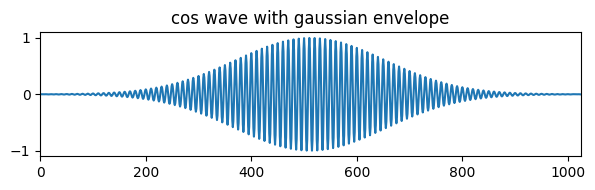

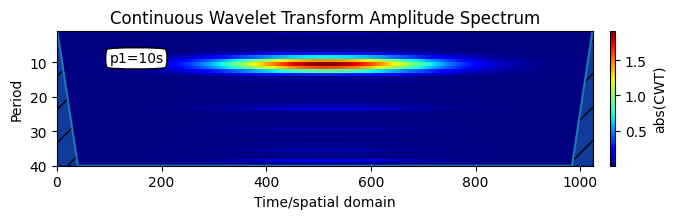

In [2]:
# let consider a timeline with 1 sample / second
ns   = 1024
time = np.arange(ns)

# and a range of scales to perform the transform
scales = scg.periods2scales( np.arange(1, 40) )

# and a periodic signal with varying amplitude
p1=10; periodic1 = np.cos(2*np.pi/p1*time) * np.exp(-((time-ns/2)/200)**2)

# plot the signal 
fig1, ax1 = plt.subplots(1, 1, figsize=(6.2,2));  
lines = ax1.plot(periodic1); 
ax1.set_xlim(0, len(time))
ax1.set_title("cos wave with gaussian envelope")
fig1.tight_layout()

# and the scaleogram
ax2 = scg.cws(periodic1, scales=scales, figsize=(6.9,2.3)); 
txt = ax2.annotate("p1=10s", xy=(100, 10), bbox=dict(boxstyle="round4", fc="w"))
plt.tight_layout()

print("Default wavelet function used to compute the transform:", scg.get_default_wavelet(), "(",
      pywt.ContinuousWavelet(scg.get_default_wavelet()).family_name, ")")